## Libraries

In [35]:
import pandas as pd 
import numpy as np
from sklearn.preprocessing import LabelEncoder

## Load Files

In [36]:
df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')

df_train.head(10)

,id,Name,Gender,Age,City,Working Professional or Student,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,0,Aaradhya,Female,49.0,Ludhiana,Working Professional,Chef,NaN,5.0,NaN,NaN,2.0,More than 8 hours,Healthy,BHM,No,1.0,2.0,No,0
1,1,Vivan,Male,26.0,Varanasi,Working Professional,Teacher,NaN,4.0,NaN,NaN,3.0,Less than 5 hours,Unhealthy,LLB,Yes,7.0,3.0,No,1
2,2,Yuvraj,Male,33.0,Visakhapatnam,Student,NaN,5.0,NaN,8.97,2.0,NaN,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
3,3,Yuvraj,Male,22.0,Mumbai,Working Professional,Teacher,NaN,5.0,NaN,NaN,1.0,Less than 5 hours,Moderate,BBA,Yes,10.0,1.0,Yes,1
4,4,Rhea,Female,30.0,Kanpur,Working Professional,Business Analyst,NaN,1.0,NaN,NaN,1.0,5-6 hours,Unhealthy,BBA,Yes,9.0,4.0,Yes,0
5,5,Vani,Female,59.0,Ahmedabad,Working Professional,Finanancial Analyst,NaN,2.0,NaN,NaN,5.0,5-6 hours,Healthy,MCA,No,7.0,5.0,No,0
6,6,Ritvik,Male,47.0,Thane,Working Professional,Chemist,NaN,5.0,NaN,NaN,2.0,7-8 hours,Moderate,MD,No,6.0,2.0,No,0
7,7,Rajveer,Male,38.0,Nashik,Working Professional,Teacher,NaN,3.0,NaN,NaN,4.0,7-8 hours,Unhealthy,B.Pharm,No,10.0,3.0,Yes,0
8,8,Aishwarya,Female,24.0,Bangalore,Student,NaN,2.0,NaN,5.90,5.0,NaN,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
9,9,Simran,Female,42.0,Patna,Working Professional,Electrician,NaN,4.0,NaN,NaN,1.0,5-6 hours,Healthy,ME,Yes,7.0,2.0,Yes,0


## **1. Reading and Understanding Data**

In [37]:
print(f"There are {df_train.shape[1]} columns and {df_train.shape[0]} rows in the train dataset.")

There are 20 columns and 140700 rows in the train dataset.


### 1.1 What data type does each column currently have? Are there any columns whose data types are not suitable for further processing?**

In [38]:
print("Column names and data type of each column:")
df_train.dtypes

Column names and data type of each column:


id                                         int64
Name                                      object
Gender                                    object
Age                                      float64
City                                      object
Working Professional or Student           object
Profession                                object
Academic Pressure                        float64
Work Pressure                            float64
CGPA                                     float64
Study Satisfaction                       float64
Job Satisfaction                         float64
Sleep Duration                            object
Dietary Habits                            object
Degree                                    object
Have you ever had suicidal thoughts ?     object
Work/Study Hours                         float64
Financial Stress                         float64
Family History of Mental Illness          object
Depression                                 int64
dtype: object

### 1.2 Does the raw data have duplicate rows?

In [39]:
print("There are {} duplicates in the dataset.".format(df_train.duplicated().sum()))

There are 0 duplicates in the dataset.


### 1.3 Check the percentage of missing data in the columns

In [40]:
print("Checking for missing values in each column:")
#Percentage of missing data
missing_percentage = df_train.isnull().mean() * 100
print("Missing ratio")
print(missing_percentage)

Checking for missing values in each column:
Missing ratio
id                                        0.000000
Name                                      0.000000
Gender                                    0.000000
Age                                       0.000000
City                                      0.000000
Working Professional or Student           0.000000
Profession                               26.034115
Academic Pressure                        80.172708
Work Pressure                            19.842217
CGPA                                     80.171997
Study Satisfaction                       80.172708
Job Satisfaction                         19.836532
Sleep Duration                            0.000000
Dietary Habits                            0.002843
Degree                                    0.001421
Have you ever had suicidal thoughts ?     0.000000
Work/Study Hours                          0.000000
Financial Stress                          0.002843
Family History of Mental

### 1.4 For each column with numeric data type, how are the values distributed?

In [41]:
def missing_ratio(column):
    return column.isna().mean() * 100

def lower_quartile(column):
    return column.quantile(0.25)

def median(column):
    return column.median()

def upper_quartile(column):
    return column.quantile(0.75)

# Select numerical columns (float64, int64) from the DataFrame
numeric_cols = df_train.select_dtypes(include=['float64', 'int64']).columns

# Dictionary to store the statistics
statistics = {
    "missing_ratio": [],
    "min": [],
    "lower_quartile": [],
    "median": [],
    "upper_quartile": [],
    "max": []
}

# Calculate statistics for each numerical column
for col in numeric_cols:
    missing_ratio_val = missing_ratio(df_train[col])
    min_val = df_train[col].min()
    lower_quartile_val = lower_quartile(df_train[col])
    median_val = median(df_train[col])
    upper_quartile_val = upper_quartile(df_train[col])
    max_val = df_train[col].max()
    
    statistics["missing_ratio"].append(missing_ratio_val)
    statistics["min"].append(min_val)
    statistics["lower_quartile"].append(lower_quartile_val)
    statistics["median"].append(median_val)
    statistics["upper_quartile"].append(upper_quartile_val)
    statistics["max"].append(max_val)

# Create a DataFrame from the statistics dictionary
num_col_info_df = pd.DataFrame(statistics, index=numeric_cols).T.round(1)
num_col_info_df


,id,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Work/Study Hours,Financial Stress,Depression
missing_ratio,0.0,0.0,80.2,19.8,80.2,80.2,19.8,0.0,0.0,0.0
min,0.0,18.0,1.0,1.0,5.0,1.0,1.0,0.0,1.0,0.0
lower_quartile,35174.8,29.0,2.0,2.0,6.3,2.0,2.0,3.0,2.0,0.0
median,70349.5,42.0,3.0,3.0,7.8,3.0,3.0,6.0,3.0,0.0
upper_quartile,105524.2,51.0,4.0,4.0,8.9,4.0,4.0,10.0,4.0,0.0
max,140699.0,60.0,5.0,5.0,10.0,5.0,5.0,12.0,5.0,1.0


### **1.5. For each column with a non-numeric data type, how are the values distributed?**

In [42]:
non_numeric_cols = df_train.select_dtypes(exclude=['float64', 'int64']).columns

# Thêm 'top_value' và 'top_freq' vào dictionary
cat_statistics = {
    "missing_ratio": [],
    "num_values": [],  
    "top_value": [],     
    "top_freq": []       
}

for col in non_numeric_cols:
    
    missing_ratio = df_train[col].isna().mean() * 100
    num_values = df_train[col].nunique()

    top_val = np.nan  
    top_fr = 0      #
    
    # Chỉ tính khi cột có giá trị
    if num_values > 0:
        top_val = df_train[col].mode().iloc[0]      # .mode() trả về giá trị phổ biến nhất
        top_fr = df_train[col].value_counts().max() # Tần suất của giá trị đó

    # Thêm kết quả vào
    cat_statistics["missing_ratio"].append(round(missing_ratio, 1))
    cat_statistics["num_values"].append(num_values)
    cat_statistics["top_value"].append(top_val)    
    cat_statistics["top_freq"].append(top_fr)       
    
cat_col_info_df = pd.DataFrame(cat_statistics, index=non_numeric_cols).T
cat_col_info_df

,Name,Gender,City,Working Professional or Student,Profession,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Family History of Mental Illness
missing_ratio,0.0,0.0,0.0,0.0,26.0,0.0,0.0,0.0,0.0,0.0
num_values,422,2,98,2,64,36,23,115,2,2
top_value,Rohan,Male,Kalyan,Working Professional,Teacher,Less than 5 hours,Moderate,Class 12,No,No
top_freq,3178,77464,6591,112799,24906,38784,49705,14729,71138,70758


Describe: 

Describe

## **2. Preprocessing**

- After identifying the basic statistical numbers that describe data, we further need to determine the features that have a large number of missing values. Such features are not useful for the analysis stage and must be removed from the dataset.

- Depending on goals, the threshold for "large" can be defined. Usually, if the percentage of missing values is greater than 75%, the column is dropped from the dataframe and an updated dataframe is returned.

In [43]:
def drop_missing_features(df: pd.DataFrame, missing_percentage: pd.Series, threshold: float = 75.0) -> pd.DataFrame:
    # Find columns with missing data percentage greater than the threshold
    cols_to_drop = missing_percentage[missing_percentage > threshold].index
    # Drop those columns from the DataFrame
    return df.drop(columns=cols_to_drop)

# Apply the function to the dataframe `df_train` using the `missing_percentage` series
train_cleaned = drop_missing_features(df_train, missing_percentage)

# Display the first few rows of the resulting dataframe
train_cleaned.head()


,id,Name,Gender,Age,City,Working Professional or Student,Profession,Work Pressure,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,0,Aaradhya,Female,49.0,Ludhiana,Working Professional,Chef,5.0,2.0,More than 8 hours,Healthy,BHM,No,1.0,2.0,No,0
1,1,Vivan,Male,26.0,Varanasi,Working Professional,Teacher,4.0,3.0,Less than 5 hours,Unhealthy,LLB,Yes,7.0,3.0,No,1
2,2,Yuvraj,Male,33.0,Visakhapatnam,Student,NaN,NaN,NaN,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
3,3,Yuvraj,Male,22.0,Mumbai,Working Professional,Teacher,5.0,1.0,Less than 5 hours,Moderate,BBA,Yes,10.0,1.0,Yes,1
4,4,Rhea,Female,30.0,Kanpur,Working Professional,Business Analyst,1.0,1.0,5-6 hours,Unhealthy,BBA,Yes,9.0,4.0,Yes,0


- Vậy là bỏ 3 cột Academic Pressure, CGPA, Study Satisfaction                                       
                   

In [44]:
# Bỏ 3 cột đó bên test luôn. Bỏ 3 cột Academic Pressure, CGPA, Study Satisfaction                                       
test_cleaned = df_test.drop(columns=['Academic Pressure', 'CGPA', 'Study Satisfaction'])    


## Xử lý các cột bị thiếu. Các cột bị thiếu
| Cột                  | Tỷ lệ thiếu (%) | Kiểu dữ liệu |
| -------------------- | --------------- | ------------ |
| **Profession**       | 26.03%          | non-num      |
| **Work Pressure**    | 19.84%          | numeric      |
| **Job Satisfaction** | 19.84%          | numeric      |
| **Dietary Habits**   | 0.0028%         | non-num      |
| **Degree**           | 0.0014%         | non-num      |
| **Financial Stress** | 0.0028%         | numeric      |


In [45]:
# Đối với cột dữ liệu số. Thay bằng giá trị xuất hiện nhiều nhất (mode) bởi vì các cột số không có outlier, kiểu dữ liệu theo dạng 1,2,3,4,5
train_cleaned['Work Pressure'].fillna(train_cleaned['Work Pressure'].mode()[0], inplace=True)
train_cleaned['Job Satisfaction'].fillna(train_cleaned['Job Satisfaction'].mode()[0], inplace=True)
train_cleaned['Financial Stress'].fillna(train_cleaned['Financial Stress'].mode()[0], inplace=True)
test_cleaned['Work Pressure'].fillna(test_cleaned['Work Pressure'].mode()[0], inplace=True)
test_cleaned['Job Satisfaction'].fillna(test_cleaned['Job Satisfaction'].mode()[0], inplace=True)
test_cleaned['Financial Stress'].fillna(test_cleaned['Financial Stress'].mode()[0], inplace=True)

In [46]:
# Đối với cột dữ liệu  non-numeric, thay bằng giá trị xuất hiện nhiều nhất (mode)
train_cleaned['Profession'].fillna(train_cleaned['Profession'].mode()[0], inplace=True)
test_cleaned['Profession'].fillna(test_cleaned['Profession'].mode()[0], inplace=True)
train_cleaned['Dietary Habits'].fillna(train_cleaned['Dietary Habits'].mode()[0], inplace=True)
test_cleaned['Dietary Habits'].fillna(test_cleaned['Dietary Habits'].mode()[0], inplace=True)
train_cleaned['Degree'].fillna(train_cleaned['Degree'].mode()[0], inplace=True)
test_cleaned['Degree'].fillna(test_cleaned['Degree'].mode()[0], inplace=True)

## Kiểm tra lại 

In [47]:
check_train = train_cleaned.isnull().sum()
check_test = test_cleaned.isnull().sum()
check_train

id                                       0
Name                                     0
Gender                                   0
Age                                      0
City                                     0
Working Professional or Student          0
Profession                               0
Work Pressure                            0
Job Satisfaction                         0
Sleep Duration                           0
Dietary Habits                           0
Degree                                   0
Have you ever had suicidal thoughts ?    0
Work/Study Hours                         0
Financial Stress                         0
Family History of Mental Illness         0
Depression                               0
dtype: int64

In [48]:
check_test

id                                       0
Name                                     0
Gender                                   0
Age                                      0
City                                     0
Working Professional or Student          0
Profession                               0
Work Pressure                            0
Job Satisfaction                         0
Sleep Duration                           0
Dietary Habits                           0
Degree                                   0
Have you ever had suicidal thoughts ?    0
Work/Study Hours                         0
Financial Stress                         0
Family History of Mental Illness         0
dtype: int64

In [49]:
# Create helper function to map sleep durations
print("Tổng số giá trị unique:", df_train['Sleep Duration'].nunique())
print("\nDanh sách các giá trị:")
print(df_train['Sleep Duration'].unique())

# 1. Định nghĩa hàm xử lý (giữ nguyên logic gom nhóm tốt nhất nãy giờ)
def map_sleep_duration(x):
    if pd.isna(x):
        return np.nan
    
    x = str(x).lower().strip()
    
    # --- NHÓM 1: Các giá trị chuẩn ---
    if "less than 5" in x or "1-2 hours" in x or "2-3 hours" in x or "3-4 hours" in x or "1-3 hours" in x or "4-5 hours" in x:
        return 4.5
    elif "5-6 hours" in x:
        return 5.5
    elif "6-7 hours" in x or "6-8 hours" in x or "1-6 hours" in x or "3-6 hours" in x: 
        return 6.0 
    elif "7-8 hours" in x or "8 hours" in x:
        return 7.5
    elif "8-9 hours" in x:
        return 8.5
    elif "more than 8" in x or "9-11 hours" in x or "10-11 hours" in x or "9-5 hours" in x or "9-6 hours" in x: 
        return 9.0
    elif "4-6 hours" in x:
        return 5.0
    elif "than 5 hours" in x:
        return 4.5
    
    # --- NHÓM 2: Rác (Noise) -> Trả về NaN ---
    else:
        return np.nan

# 2. Áp dụng hàm để tạo cột số mới (lúc này vẫn còn NaN do các giá trị rác)
train_cleaned["SleepDuration_num"] = train_cleaned["Sleep Duration"].apply(map_sleep_duration)
test_cleaned["SleepDuration_num"] = test_cleaned["Sleep Duration"].apply(map_sleep_duration)

# 3. Tính giá trị TRUNG BÌNH (Mean) trên tập Train (chỉ tính trên các dòng có số liệu hợp lệ)
sleep_mean_val = train_cleaned["SleepDuration_num"].mean()
print(f"Giá trị trung bình giờ ngủ (tính từ tập Train): {sleep_mean_val:.2f} giờ")

# 4. Điền (Fill) các ô NaN bằng giá trị trung bình vừa tính
# Lưu ý: Phải điền vào cả tập Test bằng giá trị của tập Train
train_cleaned["SleepDuration_num"].fillna(sleep_mean_val, inplace=True)
test_cleaned["SleepDuration_num"].fillna(sleep_mean_val, inplace=True)

# Kiểm tra lại xem còn NaN không
print("Số lượng NaN sau khi điền (Train):", train_cleaned["SleepDuration_num"].isna().sum())

# 5. Tạo đặc trưng is_student
train_cleaned['is_student'] = (train_cleaned['Working Professional or Student'] == 'Student').astype(int)
test_cleaned['is_student'] = (test_cleaned['Working Professional or Student'] == 'Student').astype(int)

# 6. Xóa các cột cũ không dùng nữa
train_cleaned = train_cleaned.drop(columns=["Working Professional or Student", "Sleep Duration"])
test_cleaned = test_cleaned.drop(columns=["Working Professional or Student", "Sleep Duration"])

# Xem kết quả
train_cleaned.head(10)

Tổng số giá trị unique: 36

Danh sách các giá trị:
['More than 8 hours' 'Less than 5 hours' '5-6 hours' '7-8 hours'
 'Sleep_Duration' '1-2 hours' '6-8 hours' '4-6 hours' '6-7 hours'
 '10-11 hours' '8-9 hours' '40-45 hours' '9-11 hours' '2-3 hours'
 '3-4 hours' 'Moderate' '55-66 hours' '4-5 hours' '9-6 hours' '1-3 hours'
 'Indore' '45' '1-6 hours' '35-36 hours' '8 hours' 'No' '10-6 hours'
 'than 5 hours' '49 hours' 'Unhealthy' 'Work_Study_Hours' '3-6 hours'
 '45-48 hours' '9-5' 'Pune' '9-5 hours']
Giá trị trung bình giờ ngủ (tính từ tập Train): 6.22 giờ
Số lượng NaN sau khi điền (Train): 0


,id,Name,Gender,Age,City,Profession,Work Pressure,Job Satisfaction,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression,SleepDuration_num,is_student
0,0,Aaradhya,Female,49.0,Ludhiana,Chef,5.0,2.0,Healthy,BHM,No,1.0,2.0,No,0,7.5,0
1,1,Vivan,Male,26.0,Varanasi,Teacher,4.0,3.0,Unhealthy,LLB,Yes,7.0,3.0,No,1,4.5,0
2,2,Yuvraj,Male,33.0,Visakhapatnam,Teacher,2.0,2.0,Healthy,B.Pharm,Yes,3.0,1.0,No,1,5.5,1
3,3,Yuvraj,Male,22.0,Mumbai,Teacher,5.0,1.0,Moderate,BBA,Yes,10.0,1.0,Yes,1,4.5,0
4,4,Rhea,Female,30.0,Kanpur,Business Analyst,1.0,1.0,Unhealthy,BBA,Yes,9.0,4.0,Yes,0,5.5,0
5,5,Vani,Female,59.0,Ahmedabad,Finanancial Analyst,2.0,5.0,Healthy,MCA,No,7.0,5.0,No,0,5.5,0
6,6,Ritvik,Male,47.0,Thane,Chemist,5.0,2.0,Moderate,MD,No,6.0,2.0,No,0,7.5,0
7,7,Rajveer,Male,38.0,Nashik,Teacher,3.0,4.0,Unhealthy,B.Pharm,No,10.0,3.0,Yes,0,7.5,0
8,8,Aishwarya,Female,24.0,Bangalore,Teacher,2.0,2.0,Moderate,BSc,No,3.0,2.0,Yes,0,5.5,1
9,9,Simran,Female,42.0,Patna,Electrician,4.0,1.0,Healthy,ME,Yes,7.0,2.0,Yes,0,5.5,0


## Save data

# Feature engineering

In [50]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
# Copy data
train_final = train_cleaned.copy()
test_final = test_cleaned.copy()

yes_no_cols = [
    'Have you ever had suicidal thoughts ?',
    'Family History of Mental Illness'
]

for col in yes_no_cols:
    train_final[col] = train_final[col].map({'Yes': 1, 'No': 0})
    test_final[col] = test_final[col].map({'Yes': 1, 'No': 0})

train_final['Gender'] = train_final['Gender'].map({'Male': 1, 'Female': 0})
test_final['Gender'] = test_final['Gender'].map({'Male': 1, 'Female': 0})

# Encode categorical variables
label_cols = ['Profession', 'Dietary Habits', 'Degree', 'City']
for col in label_cols:
    le = LabelEncoder()
    combines_cols = pd.concat([train_final[col], test_final[col]], axis=0).astype(str)
    le.fit(combines_cols)
    train_final[col] = le.transform(train_final[col].astype(str))
    test_final[col] = le.transform(test_final[col].astype(str))

# Final feature list
train_final.columns.tolist()


# Loại bỏ cột 'Depression' (target) và các cột định danh không có giá trị dự đoán
cols_to_drop = ['id', 'Name']

X = train_final.drop(columns=['Depression'] + cols_to_drop)
y = train_final['Depression']

# X_test dùng để nộp bài sau này (chỉ bỏ cột id, Name)
X_test_submission = test_final.drop(columns=cols_to_drop)

# 2. Chia tập dữ liệu (80% để học, 20% để thi thử)
# stratify=y giúp đảm bảo tỷ lệ người bị trầm cảm ở 2 tập là như nhau
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Kích thước tập Train:", X_train.shape)
print("Kích thước tập Val:", X_val.shape)

Kích thước tập Train: (112560, 14)
Kích thước tập Val: (28140, 14)


# Model

Đang huấn luyện mô hình...
Huấn luyện xong!

=== KẾT QUẢ BASELINE (Random Forest) ===
Accuracy: 0.9270
F1-Score: 0.7935

Chi tiết báo cáo phân loại:
              precision    recall  f1-score   support

           0       0.95      0.96      0.96     23027
           1       0.82      0.77      0.79      5113

    accuracy                           0.93     28140
   macro avg       0.88      0.87      0.87     28140
weighted avg       0.93      0.93      0.93     28140



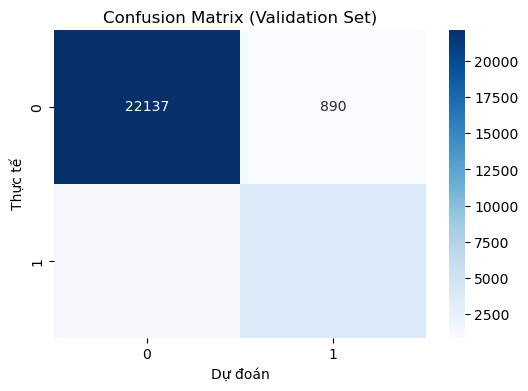

In [51]:
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
# 3. Khởi tạo và huấn luyện mô hình Random Forest
# n_estimators=100: Dùng 100 cây quyết định
# random_state=42: Giữ kết quả ổn định mỗi lần chạy
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

print("Đang huấn luyện mô hình...")
rf_model.fit(X_train, y_train)
print("Huấn luyện xong!")

# 4. Dự đoán và đánh giá trên tập Validation
y_pred = rf_model.predict(X_val)

# In kết quả
acc = accuracy_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred)

print(f"\n=== KẾT QUẢ BASELINE (Random Forest) ===")
print(f"Accuracy: {acc:.4f}")
print(f"F1-Score: {f1:.4f}")
print("\nChi tiết báo cáo phân loại:")
print(classification_report(y_val, y_pred))

# Vẽ Confusion Matrix để xem mô hình hay nhầm lẫn ở đâu
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_val, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (Validation Set)')
plt.xlabel('Dự đoán')
plt.ylabel('Thực tế')
plt.show()